In [2]:
!pip install langgraph langchain langchain-openAI tavily-python graphviz matplotlib
#no commas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.5 MB/s eta 0:00:00


In [3]:
#import getpass and os
from getpass import getpass
import os
os.environ["OPENAI_API_KEY"] = getpass("OpenAI")
os.environ["TAVILY_API_KEY"] = getpass("Tavily")

OpenAI··········
Tavily··········


In [6]:
#llm openai_api_key
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model = 'gpt-3.5-turbo', temperature=0, openai_api_key=os.environ["OPENAI_API_KEY"])

In [51]:
#tool decorator, tavily client
from tavily import TavilyClient
from langchain.tools import tool
@tool
def websearch(query:str):
  """
  search the internet for real time information, news, and facts

  Use this when the user asks about current events, details not in your training
  data

  Args: query, a string containing the search query
  """
  query = query.strip('"')
  try:
    client = TavilyClient(api_key = os.environ['TAVILY_API_KEY'])
    response = client.search(
        query = query,
        depth = 'basic',
        max_results= 3
    )
    return response
  except Exception as e:
    return str(e)
@tool
def calculator(mathexp: str):
  """
  returns the result of a mathematical expression
  use when the user asks for a calculation to be done
  Args: mathexp, a string containing the mathematical expression
  """
  try:
    return eval(mathexp)
  except Exception as e:
    return str(e)

In [52]:
#bind tools
tools = [websearch, calculator]
toolsbyname = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [53]:
#build nodes
from typing import Literal
from langgraph.graph import MessagesState, START, END, StateGraph
from langchain_core.messages import ToolMessage, SystemMessage, HumanMessage
#initialize assistant system message
ASSISTANT_SYSTEM_MESSAGE = SystemMessage(content="you are a helpful assistant")
def llm_call (state:MessagesState):
    """llm decides whether to call tool or not using messages state"""
    return {
        "messages": [llm_with_tools.invoke(
            [ASSISTANT_SYSTEM_MESSAGE] + state["messages"]
        )]
    }
def tool_node (state:dict):
    """performs tool call"""
    result =[]
    for tool_call in state["messages"][-1].tool_calls:
        tool = toolsbyname[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content = observation, tool_call_id = tool_call["id"]))
    return {"messages": result}
#actually make node parts
def should_continue(state: MessagesState) -> Literal["environment", END]:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "action"
    return END

In [54]:
#build agent
agent_builder = StateGraph(MessagesState)
#add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)
#add edges
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "action":"environment",
        END: END
    }
)
agent_builder.add_edge("environment", "llm_call")
#compile
agent = agent_builder.compile()



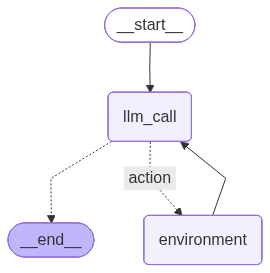

In [55]:
#display
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [56]:
def HumanMessaging():
  print("Enter your message: ")
  content = input("")
  content = content.strip('"')
  messages = [HumanMessage(content = content)]
  messages = agent.invoke({"messages": messages})
  for m in messages["messages"]:
    m.pretty_print()
HumanMessaging()

Enter your message: 
how much heavier is a moose than a deer
================================ Human Message =================================

how much heavier is a moose than a deer
================================== Ai Message ==================================
Tool Calls:
  websearch (call_3WKwM3rfISytB4y2XXvQzL57)
 Call ID: call_3WKwM3rfISytB4y2XXvQzL57
  Args:
    query: average weight of a moose
  websearch (call_ApW3RbVdD260V4cerDZTcZiL)
 Call ID: call_ApW3RbVdD260V4cerDZTcZiL
  Args:
    query: average weight of a deer
================================= Tool Message =================================

{'query': 'average weight of a moose', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.nationalforests.org/article/seven-things-to-know-about-moose/', 'title': 'Seven Things to know about Moose - National Forest Foundation', 'content': 'Moose are the largest of all deer species. Average height to shoulder – 5 – 6.5 feet. Average Weight – 8